In [160]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import LeaveOneOut, cross_val_score

In [161]:
pt_cld_data_path_1 = 'digits_pointcloud_data_sig_0.1_clip_0.2.npy'
pt_cld_data_path_2 = 'digits_pointcloud_data_sig_0.05_clip_0.1.npy'
pt_cld_data_path_3 = 'digits_pointcloud_data_sig_0.075_clip_0.2.npy'

In [162]:
def generate_directions(n):
    """Generates n regular directions in 2D."""
    angles = np.linspace(0, 2*np.pi, n, endpoint=False)
    return np.stack((np.cos(angles), np.sin(angles)), axis=1)

def scale_set(data):
    ax = 1 if data.ndim == 3 else 0
    
    centered = data - data.mean(axis=ax, keepdims=True)
    radii = np.linalg.norm(centered, axis=-1, keepdims=True)
    max_radii = np.max(radii, axis=ax, keepdims=True)
    
    return centered / max_radii

def compute_ipt(pt_cld, num_directions=20, num_thresholds=32, radius=1.0):
    """Computes ECT/IPT for a single point cloud."""
    pt_cld = scale_set(pt_cld)
    
    directions = generate_directions(num_directions)
    thresholds = np.linspace(-radius, radius, num_thresholds)

    projections = np.dot(directions, pt_cld.T)

    features = np.sum(projections[:, :, np.newaxis] <= thresholds, axis=1)
    
    return features

In [163]:
def IPT_metric(ipt_x, ipt_y, n_pts):
    num_directions = ipt_x.shape[0]
    
    # Calculate the sum of L2-norms for each direction
    total_dist = 0
    for i in range(num_directions):
        total_dist += np.linalg.norm(ipt_x[i] - ipt_y[i])/n_pts
        
    return total_dist / num_directions

def SWD(ipt_x, ipt_y, n_pts):
    num_directions = ipt_x.shape[0]

    total_dist = 0
    for i in range(ipt_x.shape[0]):
        total_dist += np.sum(np.abs(ipt_x[i]/n_pts - ipt_y[i]/n_pts)) 
    return total_dist / num_directions
        

In [164]:
labels = np.repeat(np.arange(10), 10)

## Sigma = 0.1

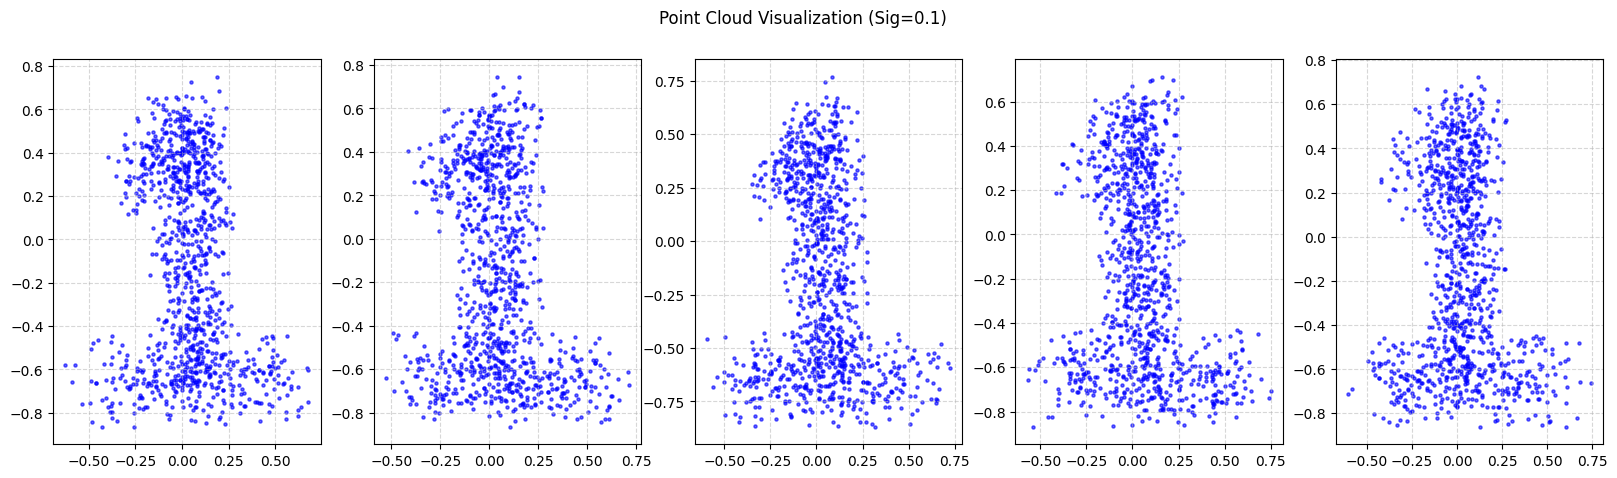

In [165]:
load_pt_cld = np.load(pt_cld_data_path_1)
fig, ax = plt.subplots(1, 5, figsize=(20, 5))
for i in range(5):
    ax[i].scatter(load_pt_cld[10 + i][:, 0], load_pt_cld[10 +i][:, 1], s=5, alpha=0.6, c='blue')   
    ax[i].grid(True, linestyle='--', alpha=0.5)    
plt.suptitle("Point Cloud Visualization (Sig=0.1)")
plt.show()

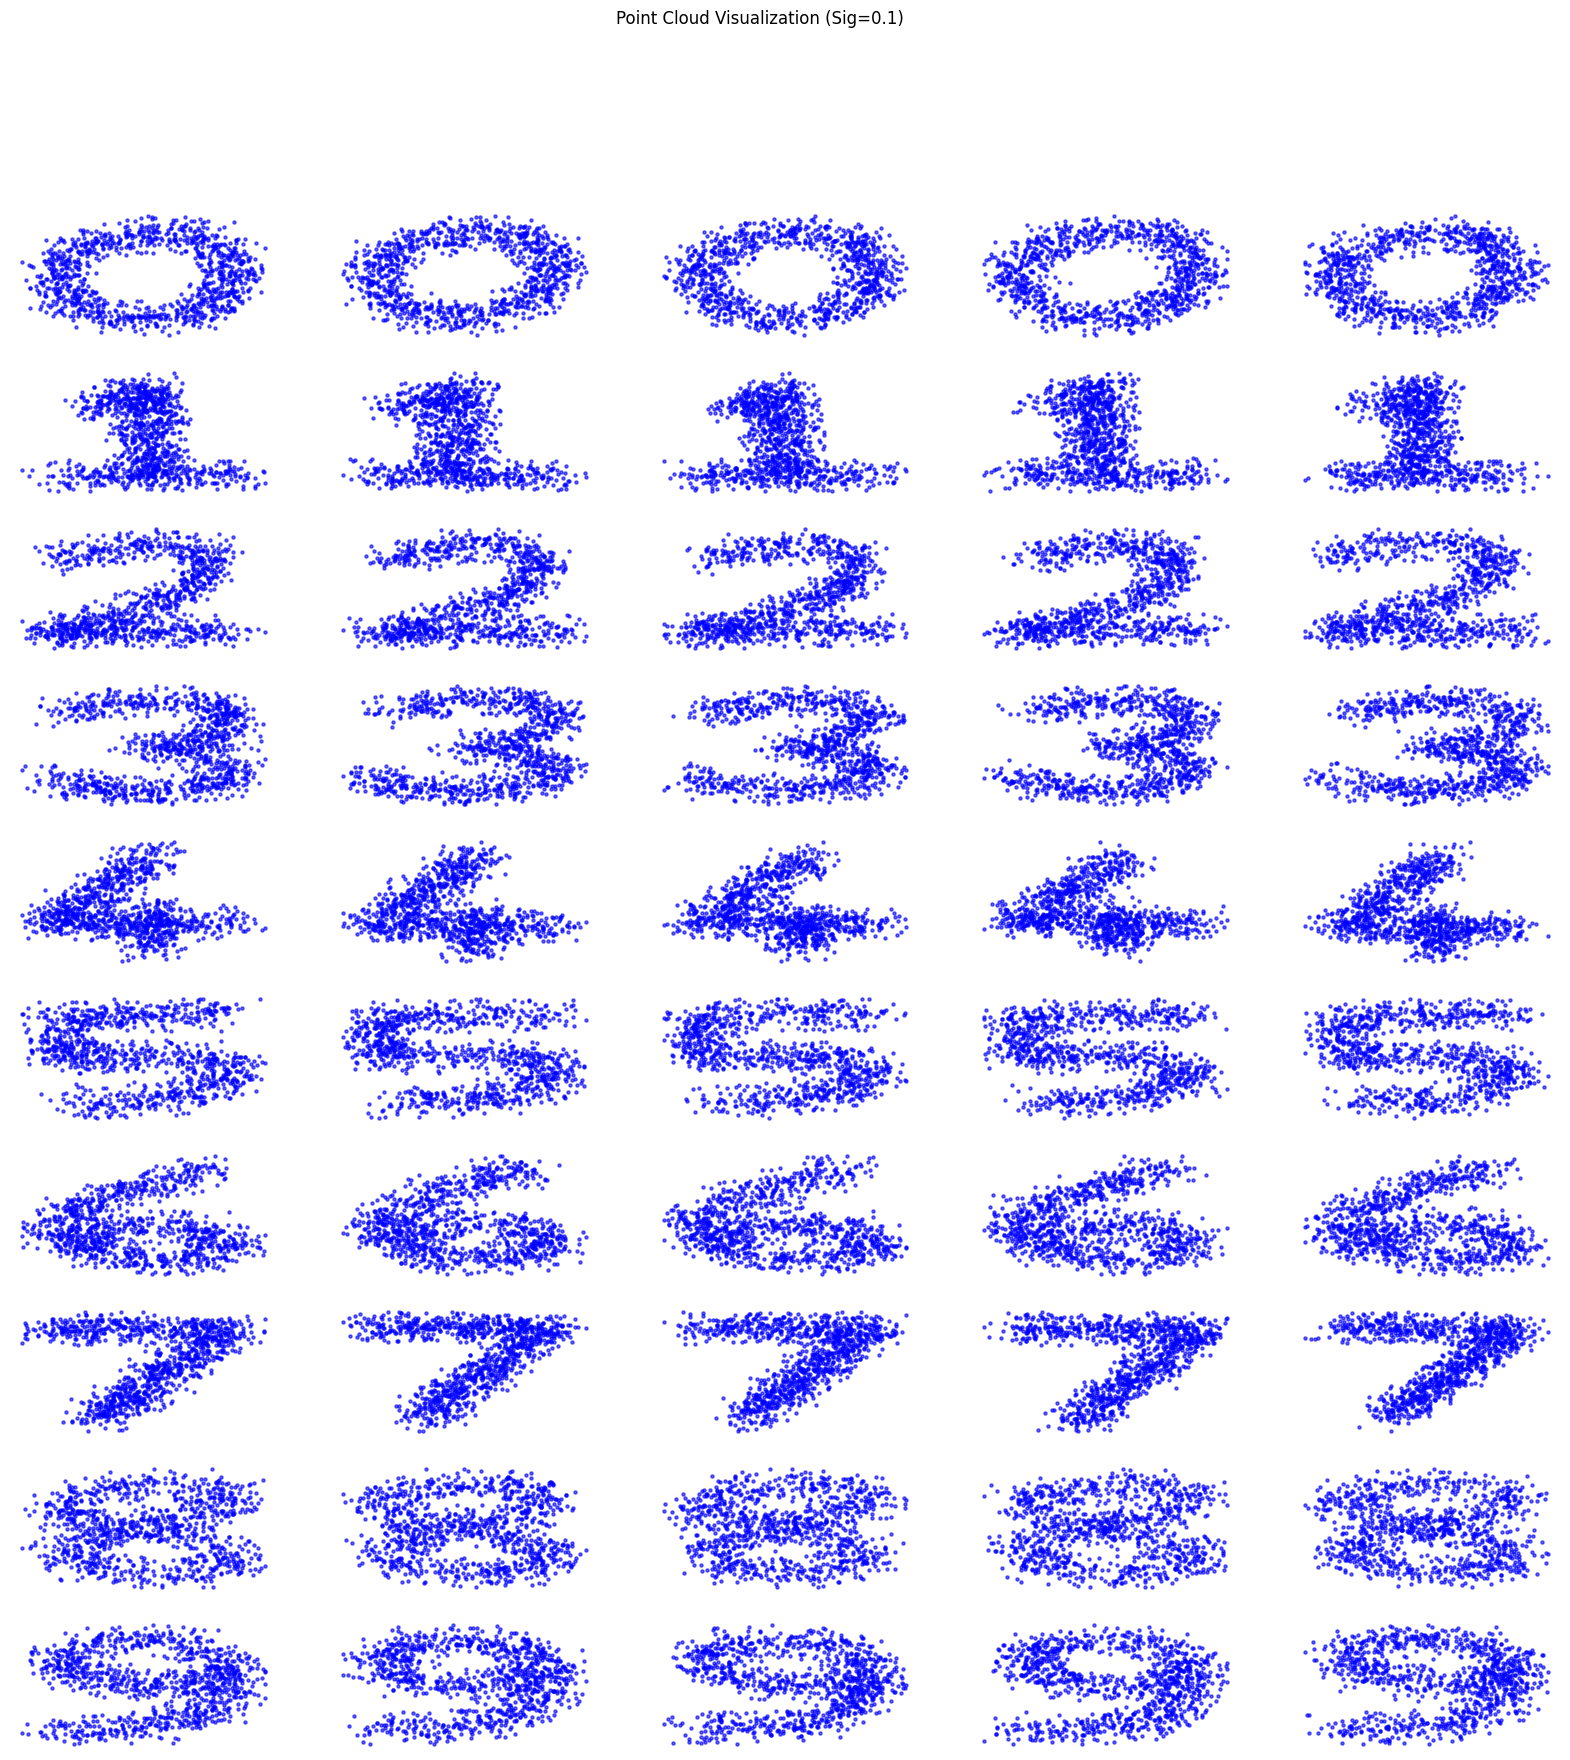

In [166]:
load_pt_cld = np.load(pt_cld_data_path_1)
fig, ax = plt.subplots(10, 5, figsize=(20, 20))
for j in range(10):
    for i in range(5):
        ax[j][i].scatter(load_pt_cld[10*j + i][:, 0], load_pt_cld[10*j +i][:, 1], s=5, alpha=0.6, c='blue')   
        ax[j][i].grid(False)   
        ax[j][i].axis('off') 
plt.suptitle("Point Cloud Visualization (Sig=0.1)")
plt.show()

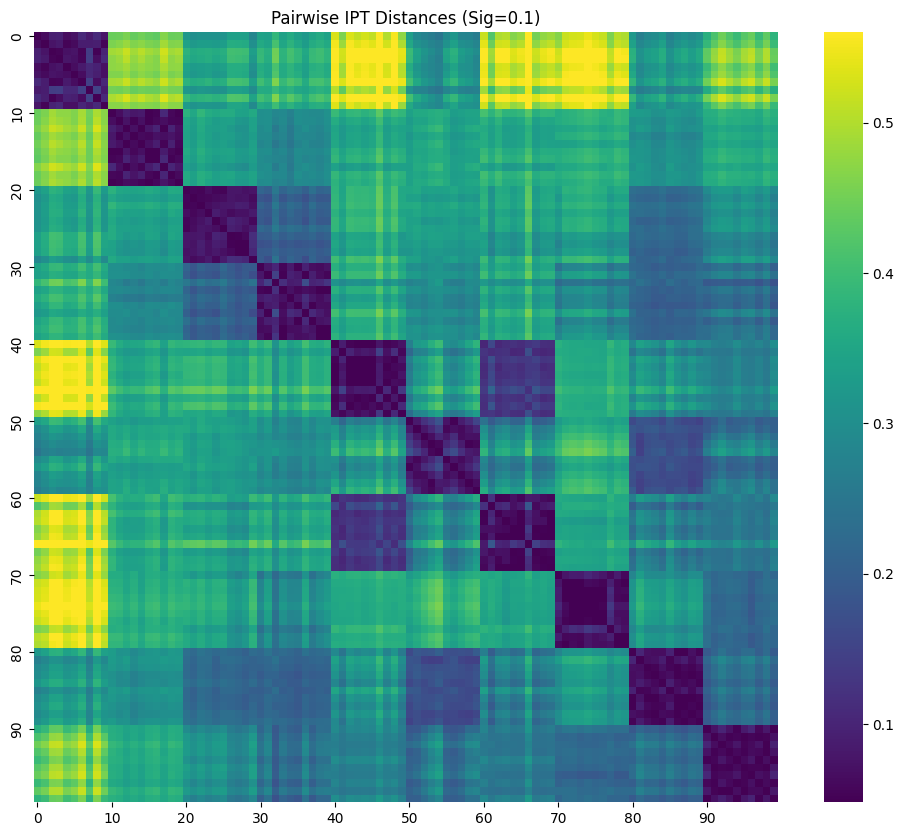

In [167]:
all_ipt = np.zeros((100, 20, 32))
for i in range(100):
    all_ipt[i] = compute_ipt(load_pt_cld[i], num_directions=20, num_thresholds=32, radius=1.0)

pairwise_distances = np.zeros((100, 100))
for i in range(100):
    for j in range(100):
        pairwise_distances[i, j] = IPT_metric(all_ipt[i], all_ipt[j], n_pts=1024)
plt.figure(figsize=(12, 10))
sns.heatmap(pairwise_distances, cmap='viridis', robust=True, xticklabels=10, yticklabels=10)
plt.title("Pairwise IPT Distances (Sig=0.1)")
plt.show()

In [169]:
# Mean Intra class distance
import numpy as np

num_classes = 10
samples_per_class = 10
total_samples = num_classes * samples_per_class

mean_intra_dist = np.zeros(num_classes)
iu = np.triu_indices(samples_per_class, k=1) 

for i in range(num_classes):
    start, end = i * samples_per_class, (i + 1) * samples_per_class
    class_matrix = pairwise_distances[start:end, start:end]
    mean_intra_dist[i] = np.mean(class_matrix[iu])

print(f"Mean Intra class distance:\n{mean_intra_dist}\n")


mean_inter_dist = np.zeros(num_classes)
all_indices = np.arange(total_samples)

for i in range(num_classes):
    start, end = i * samples_per_class, (i + 1) * samples_per_class
    inter_mask = (all_indices < start) | (all_indices >= end)
    inter_matrix = pairwise_distances[start:end, inter_mask]
    mean_inter_dist[i] = np.mean(inter_matrix)

print(f"Mean Inter class distance:\n{mean_inter_dist}")

Mean Intra class distance:
[0.08479182 0.06731524 0.07364565 0.07988615 0.06906129 0.09300282
 0.07382935 0.06838944 0.06351597 0.0635045 ]

Mean Inter class distance:
[0.4336104  0.35754125 0.31286583 0.29021805 0.33979256 0.29996908
 0.32002025 0.35461651 0.26212971 0.28518958]


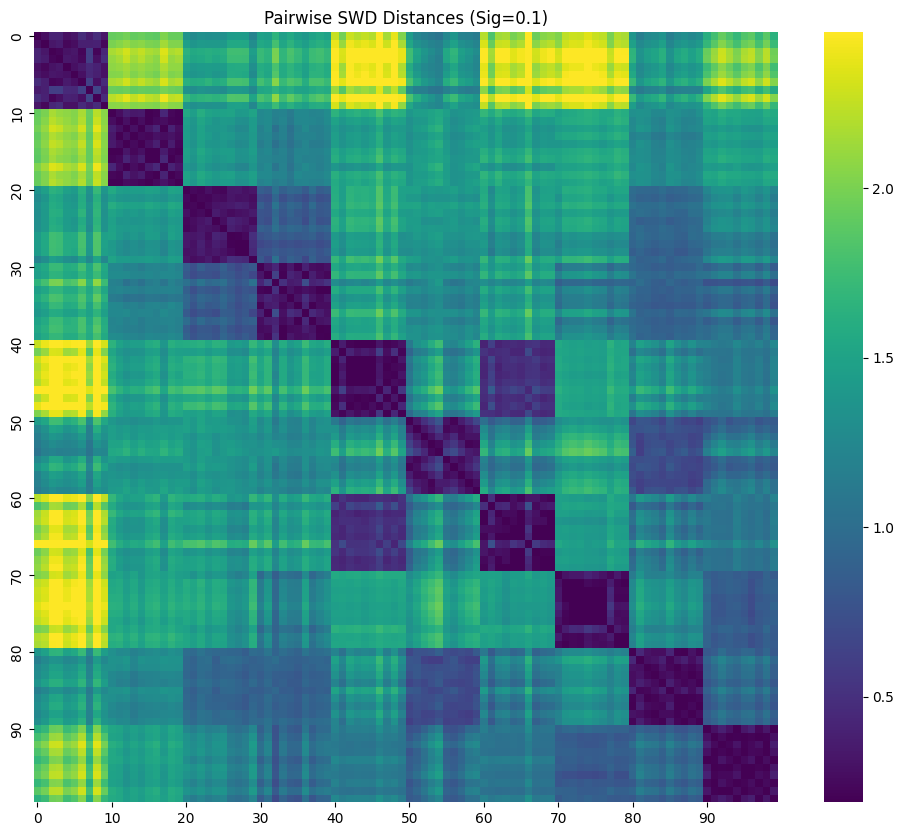

In [170]:
all_ipt = np.zeros((100, 20, 32))
for i in range(100):
    all_ipt[i] = compute_ipt(load_pt_cld[i], num_directions=20, num_thresholds=32, radius=1.0)

pairwise_distances = np.zeros((100, 100))
for i in range(100):
    for j in range(100):
        pairwise_distances[i, j] = SWD(all_ipt[i], all_ipt[j], n_pts=1024)
plt.figure(figsize=(12, 10))
sns.heatmap(pairwise_distances, cmap='viridis', robust=True, xticklabels=10, yticklabels=10)
plt.title("Pairwise SWD Distances (Sig=0.1)")
plt.show()

## Sigma = 0.075

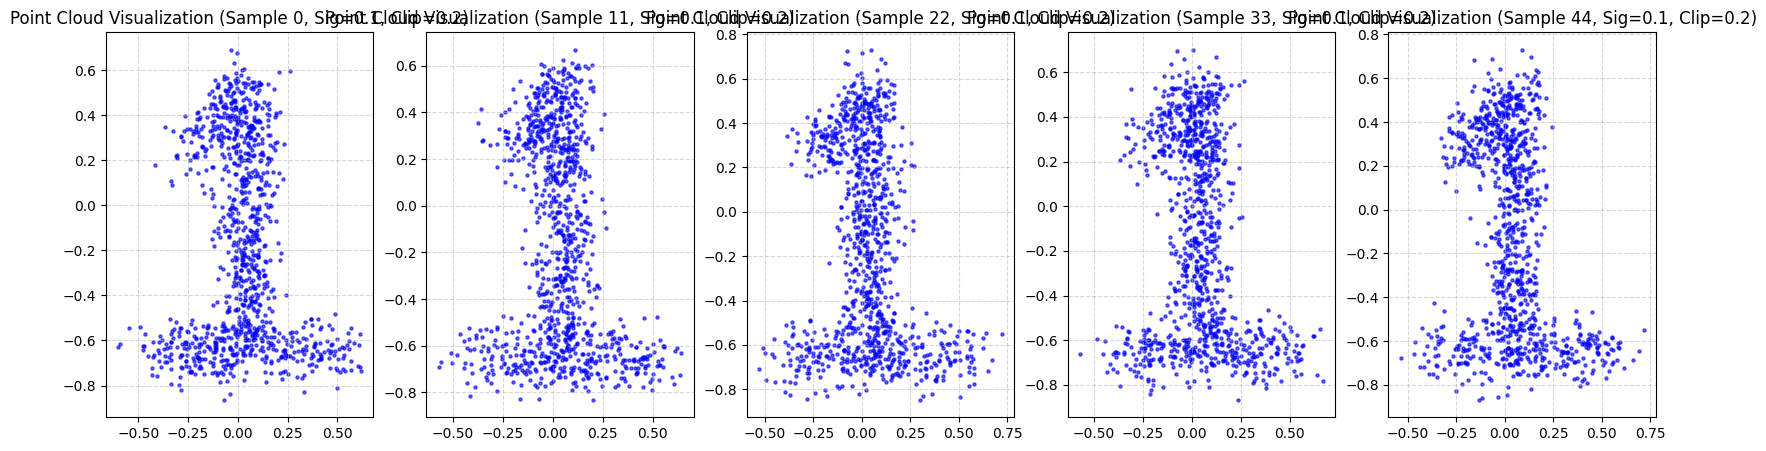

In [171]:
load_pt_cld = np.load(pt_cld_data_path_3)
fig, ax = plt.subplots(1, 5, figsize=(20, 5))
for i in range(5):
    ax[i].scatter(load_pt_cld[10 + i][:, 0], load_pt_cld[10 +i][:, 1], s=5, alpha=0.6, c='blue')
    ax[i].set_title(f'Point Cloud Visualization (Sample {10*i + i}, Sig=0.1, Clip=0.2)')    
    ax[i].grid(True, linestyle='--', alpha=0.5)    

plt.show()

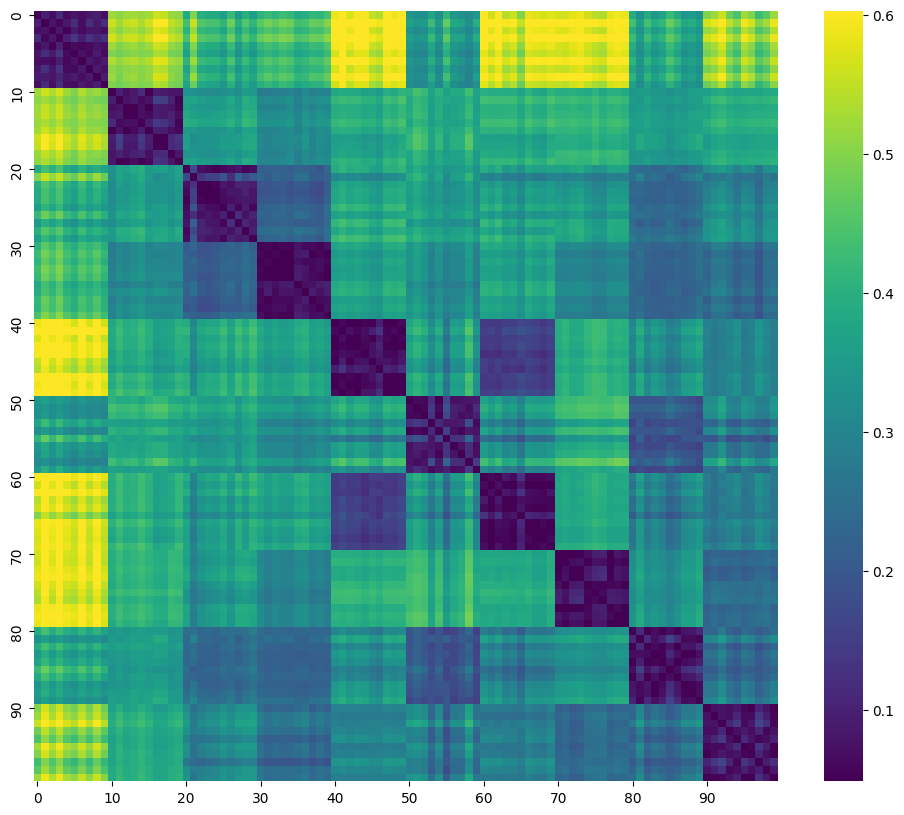

In [172]:
all_ipt = np.zeros((100, 20, 32))
for i in range(100):
    all_ipt[i] = compute_ipt(load_pt_cld[i], num_directions=20, num_thresholds=32, radius=1.0)

pairwise_distances = np.zeros((100, 100))
for i in range(100):
    for j in range(100):
        pairwise_distances[i, j] = IPT_metric(all_ipt[i], all_ipt[j], n_pts=1024)
plt.figure(figsize=(12, 10))
sns.heatmap(pairwise_distances, cmap='viridis', robust=True, xticklabels=10, yticklabels=10)
plt.show()

In [173]:
# Mean Intra class distance
import numpy as np

num_classes = 10
samples_per_class = 10
total_samples = num_classes * samples_per_class

mean_intra_dist = np.zeros(num_classes)
iu = np.triu_indices(samples_per_class, k=1) 

for i in range(num_classes):
    start, end = i * samples_per_class, (i + 1) * samples_per_class
    class_matrix = pairwise_distances[start:end, start:end]
    mean_intra_dist[i] = np.mean(class_matrix[iu])

print(f"Mean Intra class distance:\n{mean_intra_dist}\n")


mean_inter_dist = np.zeros(num_classes)
all_indices = np.arange(total_samples)

for i in range(num_classes):
    start, end = i * samples_per_class, (i + 1) * samples_per_class
    inter_mask = (all_indices < start) | (all_indices >= end)
    inter_matrix = pairwise_distances[start:end, inter_mask]
    mean_inter_dist[i] = np.mean(inter_matrix)

print(f"Mean Inter class distance:\n{mean_inter_dist}")

Mean Intra class distance:
[0.0840682  0.08641142 0.09544007 0.0652468  0.06595134 0.10032253
 0.06543075 0.0708153  0.07958992 0.08324036]

Mean Inter class distance:
[0.48369537 0.39060951 0.3301886  0.30840212 0.36223046 0.33006165
 0.34796278 0.37831738 0.28805124 0.31137423]


## Sigma = 0.05

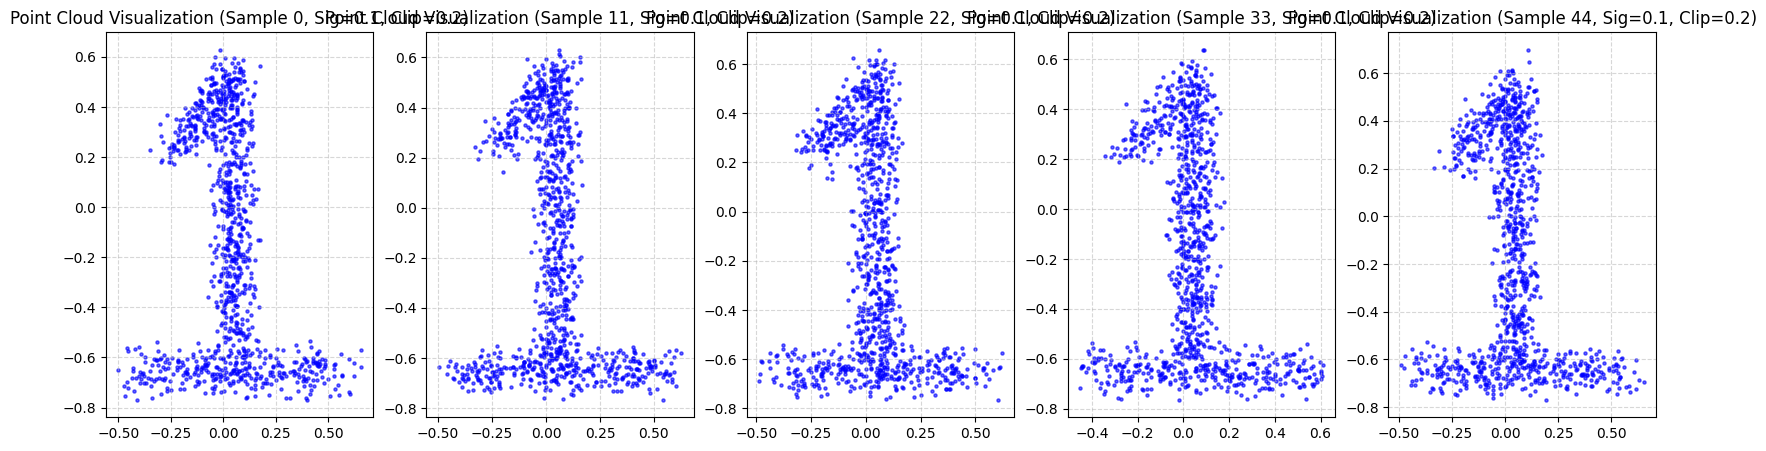

In [174]:
load_pt_cld = np.load(pt_cld_data_path_2)
fig, ax = plt.subplots(1, 5, figsize=(20, 5))
for i in range(5):
    ax[i].scatter(load_pt_cld[10 + i][:, 0], load_pt_cld[10 +i][:, 1], s=5, alpha=0.6, c='blue')
    ax[i].set_title(f'Point Cloud Visualization (Sample {10*i + i}, Sig=0.1, Clip=0.2)')    
    ax[i].grid(True, linestyle='--', alpha=0.5)    

plt.show()

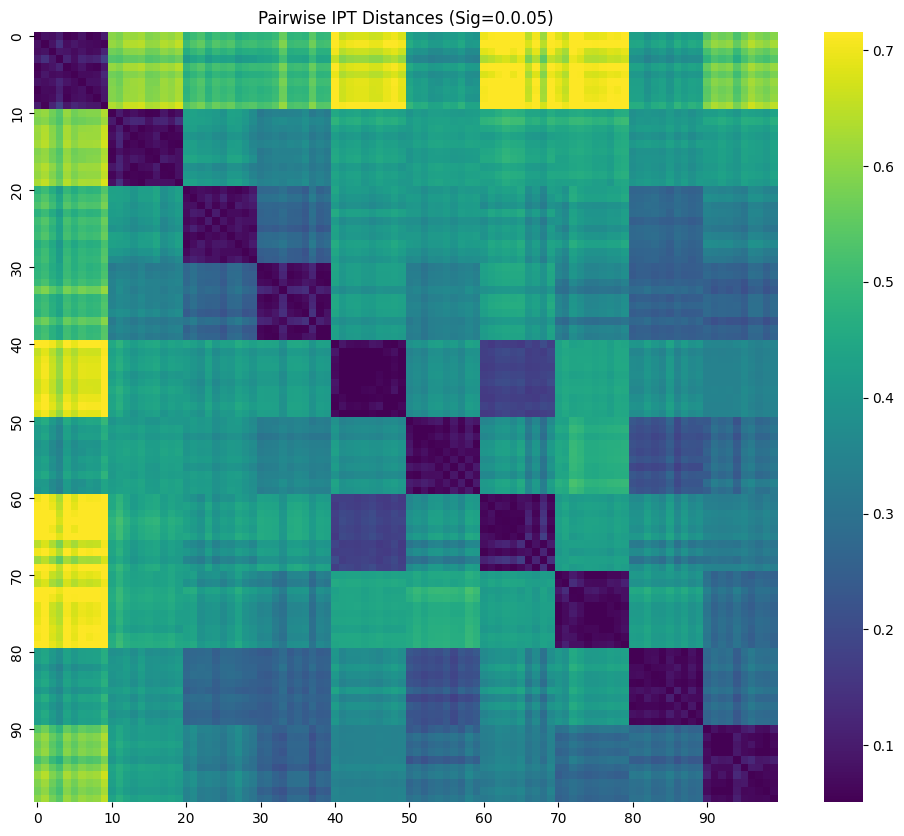

In [175]:
all_ipt = np.zeros((100, 20, 32))
for i in range(100):
    all_ipt[i] = compute_ipt(load_pt_cld[i], num_directions=20, num_thresholds=32, radius=1.0)

pairwise_distances = np.zeros((100, 100))
for i in range(100):
    for j in range(100):
        pairwise_distances[i, j] = IPT_metric(all_ipt[i], all_ipt[j], n_pts=1024)
plt.figure(figsize=(12, 10))
plt.title("Pairwise IPT Distances (Sig=0.0.05)")
sns.heatmap(pairwise_distances, cmap='viridis', robust=True, xticklabels=10, yticklabels=10)
plt.show()

In [176]:
# Mean Intra class distance
import numpy as np

num_classes = 10
samples_per_class = 10
total_samples = num_classes * samples_per_class

mean_intra_dist = np.zeros(num_classes)
iu = np.triu_indices(samples_per_class, k=1) 

for i in range(num_classes):
    start, end = i * samples_per_class, (i + 1) * samples_per_class
    class_matrix = pairwise_distances[start:end, start:end]
    mean_intra_dist[i] = np.mean(class_matrix[iu])

print(f"Mean Intra class distance:\n{mean_intra_dist}\n")


mean_inter_dist = np.zeros(num_classes)
all_indices = np.arange(total_samples)

for i in range(num_classes):
    start, end = i * samples_per_class, (i + 1) * samples_per_class
    inter_mask = (all_indices < start) | (all_indices >= end)
    inter_matrix = pairwise_distances[start:end, inter_mask]
    mean_inter_dist[i] = np.mean(inter_matrix)

print(f"Mean Inter class distance:\n{mean_inter_dist}")

Mean Intra class distance:
[0.08524209 0.0767508  0.07741901 0.08169285 0.05673081 0.07325226
 0.08173325 0.070144   0.06796252 0.07259024]

Mean Inter class distance:
[0.5656606  0.43494795 0.37566673 0.34966926 0.40662415 0.36758127
 0.40822768 0.43564846 0.33453672 0.34761644]


## Sigma 0.02

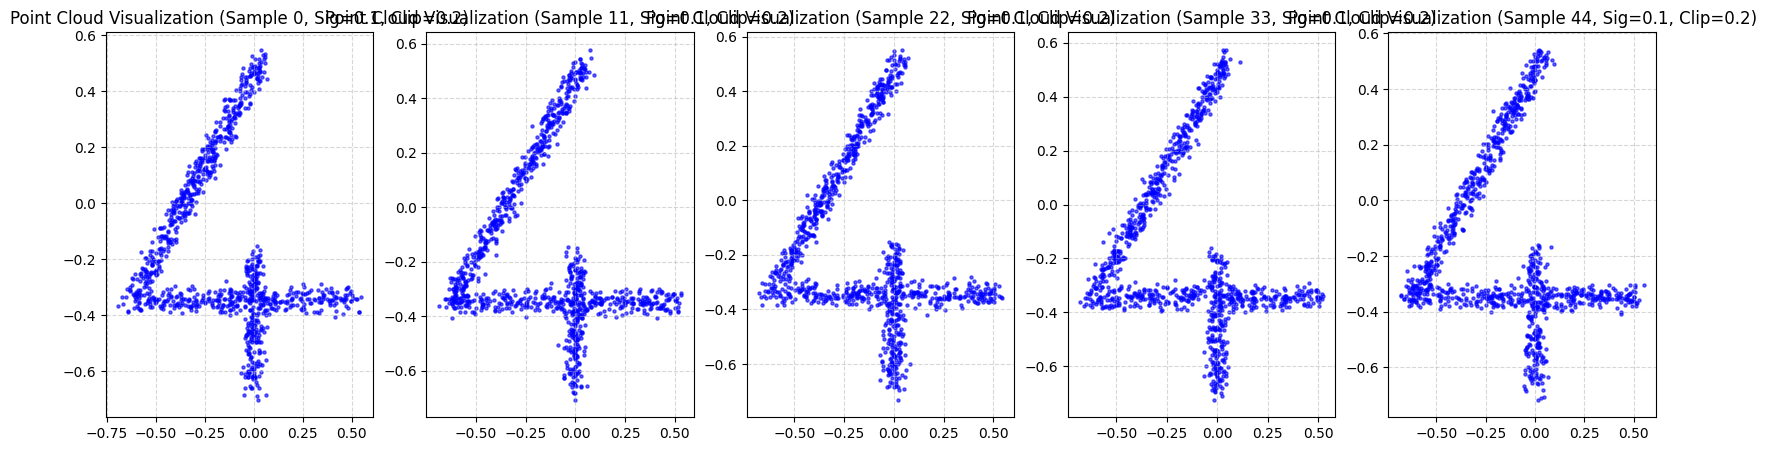

In [177]:
load_pt_cld = np.load('digits_pointcloud_data_sig_0.02_clip_0.1.npy')
# digit
j = 4

fig, ax = plt.subplots(1, 5, figsize=(20, 5))
for i in range(5):
    ax[i].scatter(load_pt_cld[10*j + i][:, 0], load_pt_cld[10*j +i][:, 1], s=5, alpha=0.6, c='blue')
    ax[i].set_title(f'Point Cloud Visualization (Sample {10*i + i}, Sig=0.1, Clip=0.2)')    
    ax[i].grid(True, linestyle='--', alpha=0.5)    

plt.show()

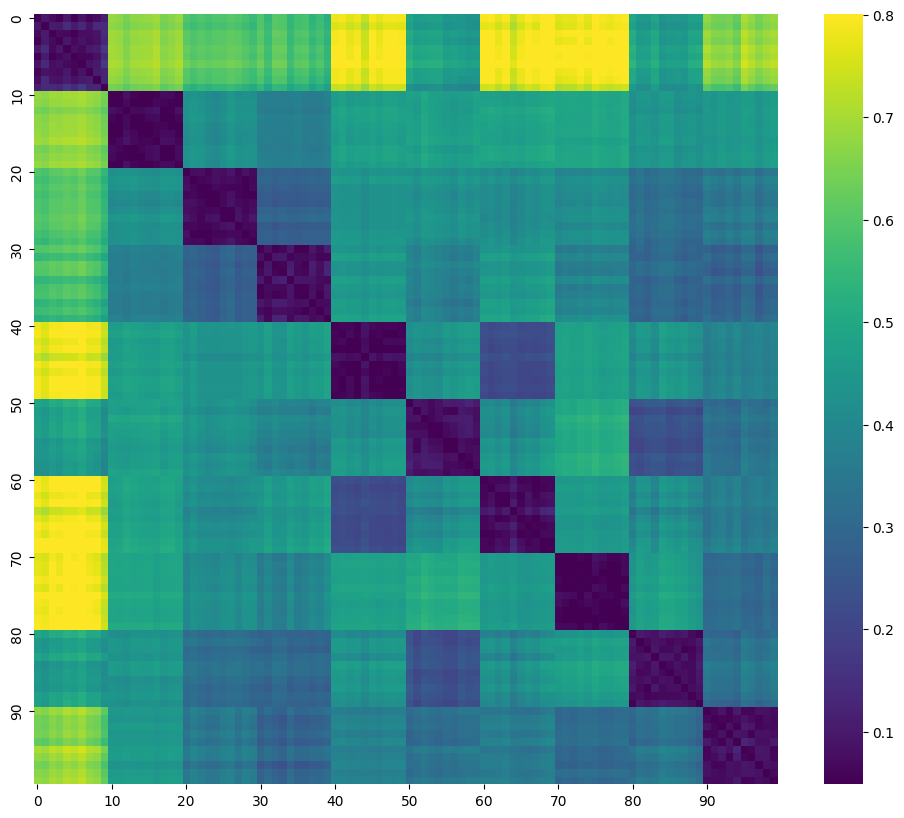

In [178]:
all_ipt = np.zeros((100, 20, 32))
for i in range(100):
    all_ipt[i] = compute_ipt(load_pt_cld[i], num_directions=20, num_thresholds=32, radius=1.0)

pairwise_distances = np.zeros((100, 100))
for i in range(100):
    for j in range(100):
        pairwise_distances[i, j] = IPT_metric(all_ipt[i], all_ipt[j], n_pts=1024)
plt.figure(figsize=(12, 10))
sns.heatmap(pairwise_distances, cmap='viridis', robust=True, xticklabels=10, yticklabels=10)
plt.show()

In [179]:
# Mean Intra class distance
import numpy as np

num_classes = 10
samples_per_class = 10
total_samples = num_classes * samples_per_class

mean_intra_dist = np.zeros(num_classes)
iu = np.triu_indices(samples_per_class, k=1) 

for i in range(num_classes):
    start, end = i * samples_per_class, (i + 1) * samples_per_class
    class_matrix = pairwise_distances[start:end, start:end]
    mean_intra_dist[i] = np.mean(class_matrix[iu])

print(f"Mean Intra class distance:\n{mean_intra_dist}\n")


mean_inter_dist = np.zeros(num_classes)
all_indices = np.arange(total_samples)

for i in range(num_classes):
    start, end = i * samples_per_class, (i + 1) * samples_per_class
    inter_mask = (all_indices < start) | (all_indices >= end)
    inter_matrix = pairwise_distances[start:end, inter_mask]
    mean_inter_dist[i] = np.mean(inter_matrix)

print(f"Mean Inter class distance:\n{mean_inter_dist}")

Mean Intra class distance:
[0.09528541 0.05730529 0.06656928 0.07802533 0.05937466 0.08275552
 0.07248507 0.05432762 0.07936455 0.07650206]

Mean Inter class distance:
[0.64490845 0.4752278  0.40742951 0.38681249 0.45458104 0.40910045
 0.4469265  0.47821202 0.37879361 0.38582714]


## Rotation

In [180]:
import numpy as np

def rotate_point_cloud(batch_data, angle_range= np.pi/ 10):
    """
    Randomly rotate the point clouds along the Z-axis (2D plane rotation).
    
    Args:
        batch_data: numpy array of shape (B, N, 2) 
                    B = Batch size (90 in your case)
                    N = Number of points (1024)
    Returns:
        rotated_data: numpy array of same shape
    """
    rotated_data = np.zeros(batch_data.shape, dtype=np.float32)
    
    for k in range(batch_data.shape[0]):
        # 1. Pick a random angle between 0 and 2*pi (0 to 360 degrees)
        rotation_angle = np.random.uniform() * angle_range
        cosval = np.cos(rotation_angle)
        sinval = np.sin(rotation_angle)
        
        # 2. Create the 2D Rotation Matrix
        # [ cos  -sin ]
        # [ sin   cos ]
        rotation_matrix = np.array([[cosval, -sinval],
                                    [sinval, cosval]])
        
        # 3. Apply rotation to the N points
        # shape: (N, 2) * (2, 2) -> (N, 2)
        shape_pc = batch_data[k, ...]
        rotated_data[k, ...] = np.dot(shape_pc, rotation_matrix)
        
    return rotated_data

### 15 Degree Rotation

Text(0.5, 0.98, 'Point Cloud Visualization of Rotated Digits (max 15 degrees)')

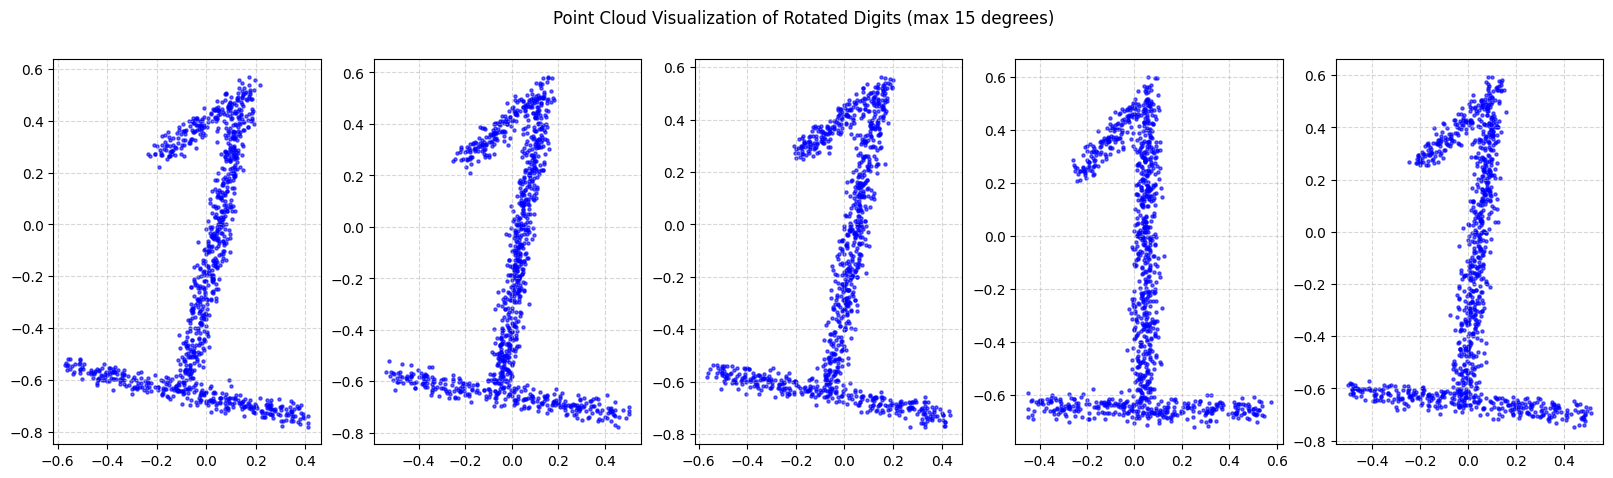

In [181]:
load_pt_cld = np.load('digits_pointcloud_data_sig_0.02_clip_0.1.npy')
rotated_pt_cld = rotate_point_cloud(load_pt_cld, angle_range= np.pi/12)
fig, ax = plt.subplots(1, 5, figsize=(20, 5))
j = 1
for i in range(5):
    ax[i].scatter(rotated_pt_cld[10*j + i][:, 0], rotated_pt_cld[10*j +i][:, 1], s=5, alpha=0.6, c='blue')
    ax[i].grid(True, linestyle='--', alpha=0.5)
plt.suptitle("Point Cloud Visualization of Rotated Digits (max 15 degrees)")

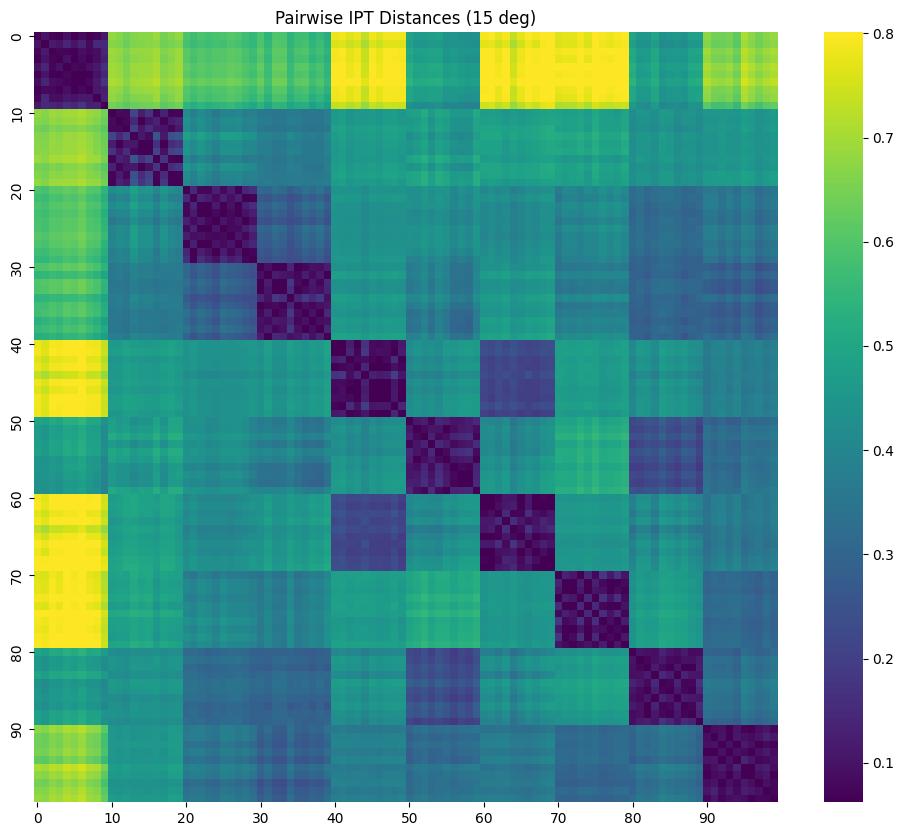

In [182]:
all_ipt = np.zeros((100, 20, 32))
for i in range(100):
    all_ipt[i] = compute_ipt(rotated_pt_cld[i], num_directions=20, num_thresholds=32, radius=1.0)

pairwise_distances = np.zeros((100, 100))
for i in range(100):
    for j in range(100):
        pairwise_distances[i, j] = IPT_metric(all_ipt[i], all_ipt[j], n_pts=1024)
plt.figure(figsize=(12, 10))
plt.title("Pairwise IPT Distances (15 deg)")
sns.heatmap(pairwise_distances, cmap='viridis', robust=True, xticklabels=10, yticklabels=10)
plt.show()

In [183]:
# Mean Intra class distance
import numpy as np

num_classes = 10
samples_per_class = 10
total_samples = num_classes * samples_per_class

mean_intra_dist = np.zeros(num_classes)
iu = np.triu_indices(samples_per_class, k=1) 

for i in range(num_classes):
    start, end = i * samples_per_class, (i + 1) * samples_per_class
    class_matrix = pairwise_distances[start:end, start:end]
    mean_intra_dist[i] = np.mean(class_matrix[iu])

print(f"Mean Intra class distance:\n{mean_intra_dist}\n")


mean_inter_dist = np.zeros(num_classes)
all_indices = np.arange(total_samples)

for i in range(num_classes):
    start, end = i * samples_per_class, (i + 1) * samples_per_class
    inter_mask = (all_indices < start) | (all_indices >= end)
    inter_matrix = pairwise_distances[start:end, inter_mask]
    mean_inter_dist[i] = np.mean(inter_matrix)

print(f"Mean Inter class distance:\n{mean_inter_dist}")

Mean Intra class distance:
[0.09706173 0.12855699 0.09884957 0.10228128 0.09257748 0.11081151
 0.09490559 0.09718675 0.10032707 0.08840203]

Mean Inter class distance:
[0.64399823 0.47125704 0.40350638 0.38485055 0.45124648 0.40711337
 0.446509   0.47485776 0.37849766 0.38554871]


### 30 Degree Rotation

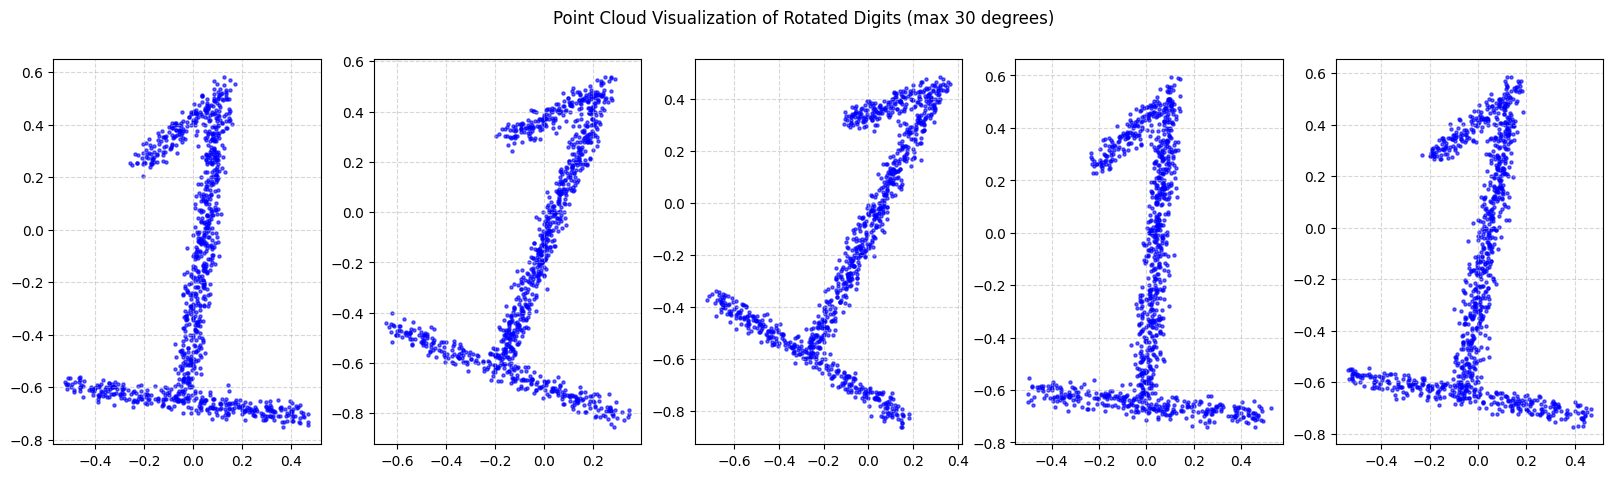

In [200]:
load_pt_cld = np.load('digits_pointcloud_data_sig_0.02_clip_0.1.npy')
rotated_pt_cld = rotate_point_cloud(load_pt_cld, angle_range= np.pi/6)
fig, ax = plt.subplots(1, 5, figsize=(20, 5))
j = 1
for i in range(5):
    ax[i].scatter(rotated_pt_cld[10*j + i][:, 0], rotated_pt_cld[10*j +i][:, 1], s=5, alpha=0.6, c='blue') 
    ax[i].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Point Cloud Visualization of Rotated Digits (max 30 degrees)")
plt.show()

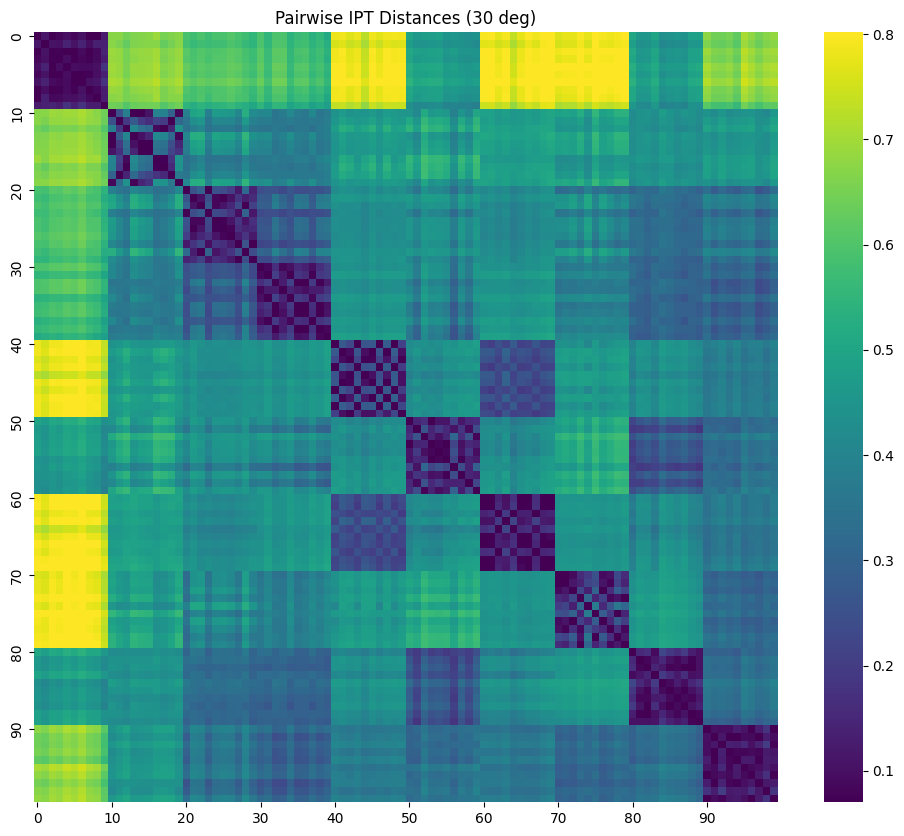

In [201]:
all_ipt = np.zeros((100, 20, 32))
for i in range(100):
    all_ipt[i] = compute_ipt(rotated_pt_cld[i], num_directions=20, num_thresholds=32, radius=1.0)

pairwise_distances = np.zeros((100, 100))
for i in range(100):
    for j in range(100):
        pairwise_distances[i, j] = IPT_metric(all_ipt[i], all_ipt[j], n_pts=1024)
plt.figure(figsize=(12, 10))
plt.title("Pairwise IPT Distances (30 deg)")
sns.heatmap(pairwise_distances, cmap='viridis', robust=True, xticklabels=10, yticklabels=10)
plt.show()

In [202]:
# Mean Intra class distance
import numpy as np

num_classes = 10
samples_per_class = 10
total_samples = num_classes * samples_per_class

mean_intra_dist = np.zeros(num_classes)
iu = np.triu_indices(samples_per_class, k=1) 

for i in range(num_classes):
    start, end = i * samples_per_class, (i + 1) * samples_per_class
    class_matrix = pairwise_distances[start:end, start:end]
    mean_intra_dist[i] = np.mean(class_matrix[iu])

print(f"Mean Intra class distance:\n{mean_intra_dist}\n")
print(np.mean(mean_intra_dist))


mean_inter_dist = np.zeros(num_classes)
all_indices = np.arange(total_samples)

for i in range(num_classes):
    start, end = i * samples_per_class, (i + 1) * samples_per_class
    inter_mask = (all_indices < start) | (all_indices >= end)
    inter_matrix = pairwise_distances[start:end, inter_mask]
    mean_inter_dist[i] = np.mean(inter_matrix)

print(f"Mean Inter class distance:\n{mean_inter_dist}")
print(np.mean(mean_inter_dist))

Mean Intra class distance:
[0.10028959 0.23863342 0.16410912 0.1351789  0.17064206 0.15591541
 0.11920093 0.17746432 0.11947329 0.10834402]

0.14892510469728445
Mean Inter class distance:
[0.64407153 0.47731646 0.40713365 0.39158715 0.45338716 0.41738191
 0.44938566 0.47693532 0.3830889  0.38874659]
0.4489034351824393


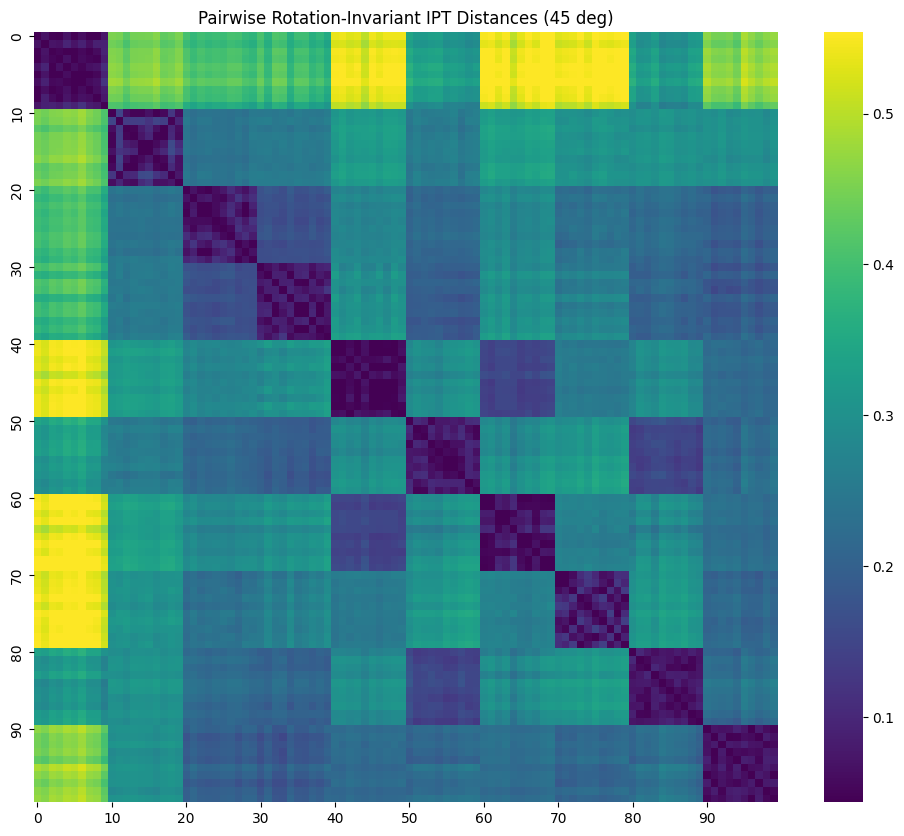

In [203]:
num_d = 15
num_t = 16
all_ipt = np.zeros((100, num_d, num_t))
for i in range(100):
    all_ipt[i] = compute_ipt(rotated_pt_cld[i], num_directions=num_d, num_thresholds=num_t, radius=1.0)

pairwise_distances = np.zeros((100, 100))
for i in range(100):
    for j in range(100):
        min = float('inf')
        for k in range(-num_d//4, num_d//4):
            d = IPT_metric(all_ipt[i], np.roll(all_ipt[j], -k-1, axis=0), n_pts=1024)
            if d < min:
                min = d
        pairwise_distances[i, j] = min
plt.figure(figsize=(12, 10))
plt.title("Pairwise Rotation-Invariant IPT Distances (45 deg)")
sns.heatmap(pairwise_distances, cmap='viridis', robust=True, xticklabels=10, yticklabels=10)
plt.show()

In [204]:
# Mean Intra class distance
import numpy as np

num_classes = 10
samples_per_class = 10
total_samples = num_classes * samples_per_class

mean_intra_dist = np.zeros(num_classes)
iu = np.triu_indices(samples_per_class, k=1) 

for i in range(num_classes):
    start, end = i * samples_per_class, (i + 1) * samples_per_class
    class_matrix = pairwise_distances[start:end, start:end]
    mean_intra_dist[i] = np.mean(class_matrix[iu])

print(f"Mean Intra class distance:\n{mean_intra_dist}\n")
print(np.mean(mean_intra_dist))

mean_inter_dist = np.zeros(num_classes)
all_indices = np.arange(total_samples)

for i in range(num_classes):
    start, end = i * samples_per_class, (i + 1) * samples_per_class
    inter_mask = (all_indices < start) | (all_indices >= end)
    inter_matrix = pairwise_distances[start:end, inter_mask]
    mean_inter_dist[i] = np.mean(inter_matrix)

print(f"Mean Inter class distance:\n{mean_inter_dist}")
print(np.mean(mean_inter_dist))

Mean Intra class distance:
[0.06418025 0.08648103 0.07790651 0.07537476 0.05194681 0.07770318
 0.06814905 0.087668   0.07177004 0.06749074]

0.07286703727289777
Mean Inter class distance:
[0.43951746 0.30607274 0.24763103 0.25145503 0.29346906 0.25125816
 0.29879612 0.30162879 0.25747084 0.25099925]
0.28982984722649285


### 45 Degree Rotation

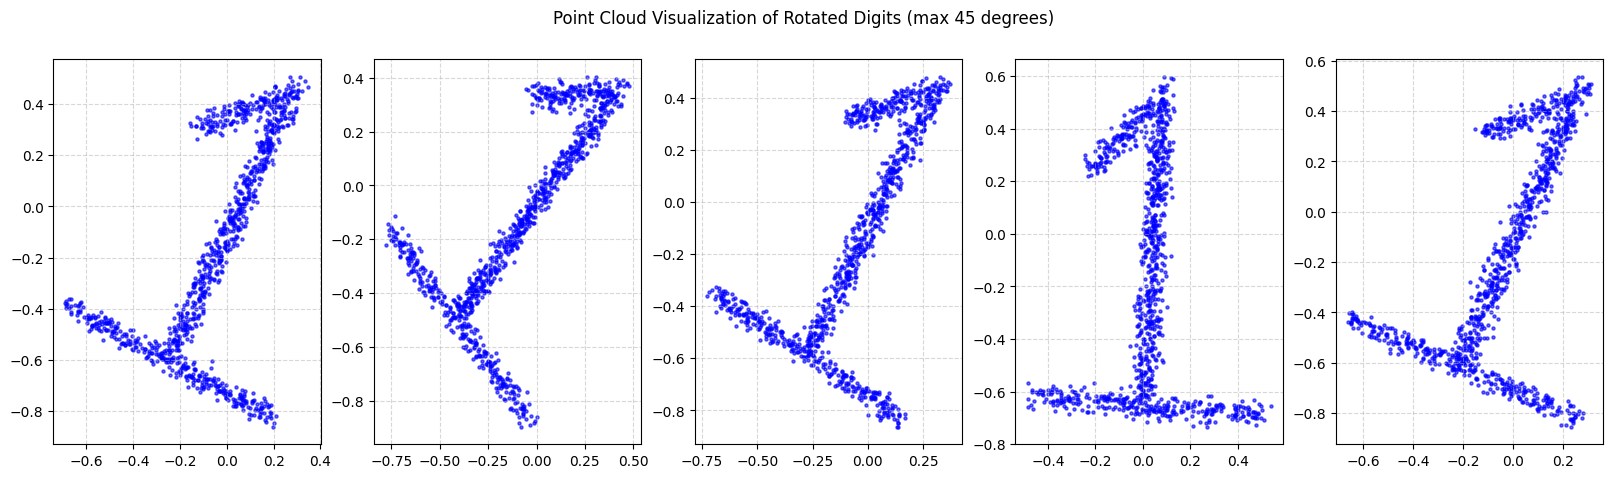

In [187]:
load_pt_cld = np.load('digits_pointcloud_data_sig_0.02_clip_0.1.npy')
rotated_pt_cld = rotate_point_cloud(load_pt_cld, angle_range=np.pi/4)
fig, ax = plt.subplots(1, 5, figsize=(20, 5))
j = 1
for i in range(5):
    ax[i].scatter(rotated_pt_cld[10*j + i][:, 0], rotated_pt_cld[10*j +i][:, 1], s=5, alpha=0.6, c='blue') 
    ax[i].grid(True, linestyle='--', alpha=0.5)
plt.suptitle("Point Cloud Visualization of Rotated Digits (max 45 degrees)")
plt.show()

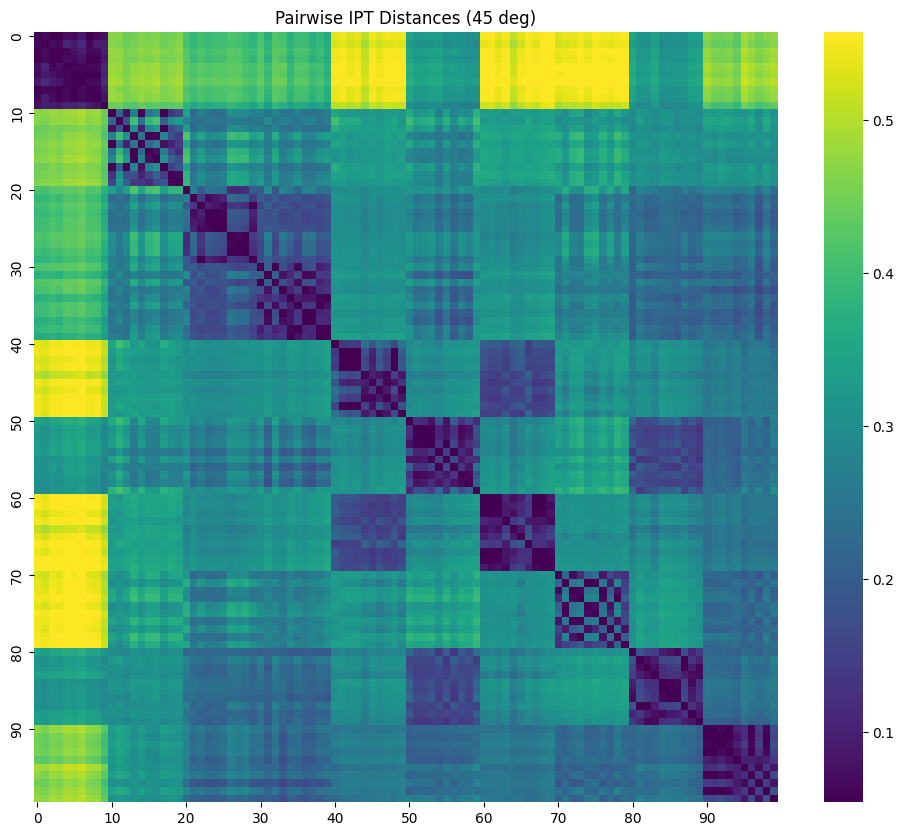

In [188]:
num_d = 15
num_t = 16
all_ipt = np.zeros((100, num_d, num_t))
for i in range(100):
    all_ipt[i] = compute_ipt(rotated_pt_cld[i], num_directions=num_d, num_thresholds=num_t, radius=1.0)

pairwise_distances = np.zeros((100, 100))
for i in range(100):
    for j in range(100):
        pairwise_distances[i, j] = IPT_metric(all_ipt[i], all_ipt[j], n_pts=1024)
plt.figure(figsize=(12, 10))
plt.title("Pairwise IPT Distances (45 deg)")
sns.heatmap(pairwise_distances, cmap='viridis', robust=True, xticklabels=10, yticklabels=10)
plt.show()

In [189]:
# Mean Intra class distance
import numpy as np

num_classes = 10
samples_per_class = 10
total_samples = num_classes * samples_per_class

mean_intra_dist = np.zeros(num_classes)
iu = np.triu_indices(samples_per_class, k=1) 

for i in range(num_classes):
    start, end = i * samples_per_class, (i + 1) * samples_per_class
    class_matrix = pairwise_distances[start:end, start:end]
    mean_intra_dist[i] = np.mean(class_matrix[iu])

print(f"Mean Intra class distance:\n{mean_intra_dist}\n")


mean_inter_dist = np.zeros(num_classes)
all_indices = np.arange(total_samples)

for i in range(num_classes):
    start, end = i * samples_per_class, (i + 1) * samples_per_class
    inter_mask = (all_indices < start) | (all_indices >= end)
    inter_matrix = pairwise_distances[start:end, inter_mask]
    mean_inter_dist[i] = np.mean(inter_matrix)

print(f"Mean Inter class distance:\n{mean_inter_dist}")

Mean Intra class distance:
[0.07268108 0.19697655 0.13815357 0.11191911 0.13173458 0.11877026
 0.0953071  0.16421411 0.11050221 0.09953626]

Mean Inter class distance:
[0.44763612 0.33194353 0.28154349 0.2753861  0.31467614 0.27860029
 0.31410826 0.33076534 0.26768857 0.27212043]


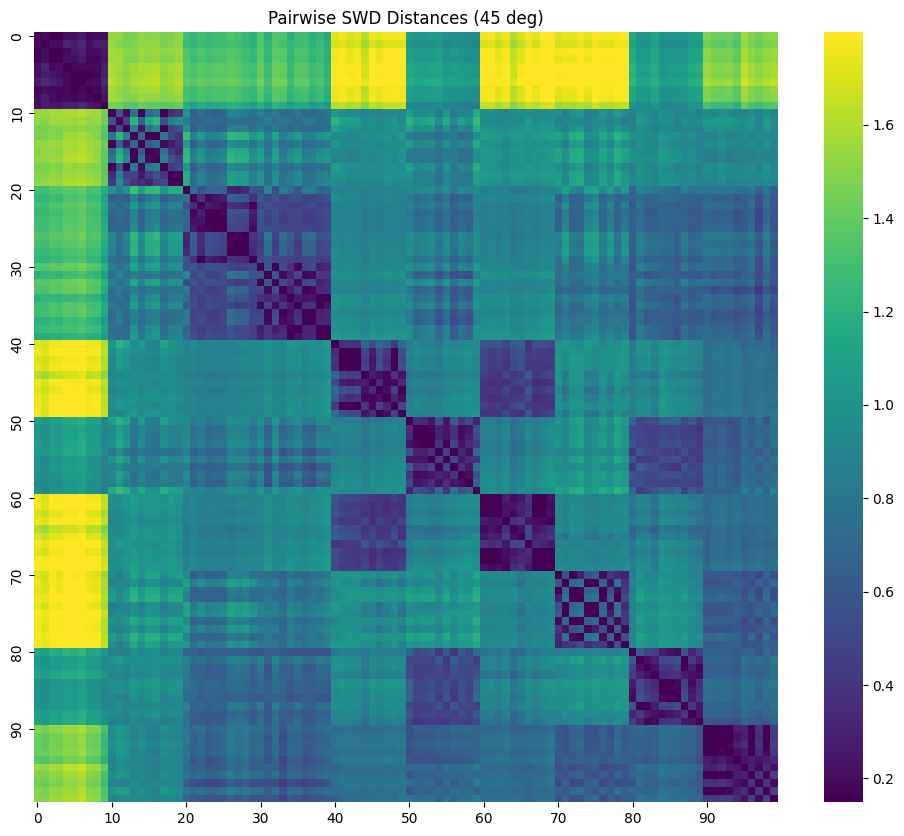

In [190]:
num_d = 15
num_t = 16
all_ipt = np.zeros((100, num_d, num_t))
for i in range(100):
    all_ipt[i] = compute_ipt(rotated_pt_cld[i], num_directions=num_d, num_thresholds=num_t, radius=1.0)

pairwise_distances = np.zeros((100, 100))
for i in range(100):
    for j in range(100):
        pairwise_distances[i, j] = SWD(all_ipt[i], all_ipt[j], n_pts=1024)
plt.figure(figsize=(12, 10))
plt.title("Pairwise SWD Distances (45 deg)")
sns.heatmap(pairwise_distances, cmap='viridis', robust=True, xticklabels=10, yticklabels=10)
plt.show()

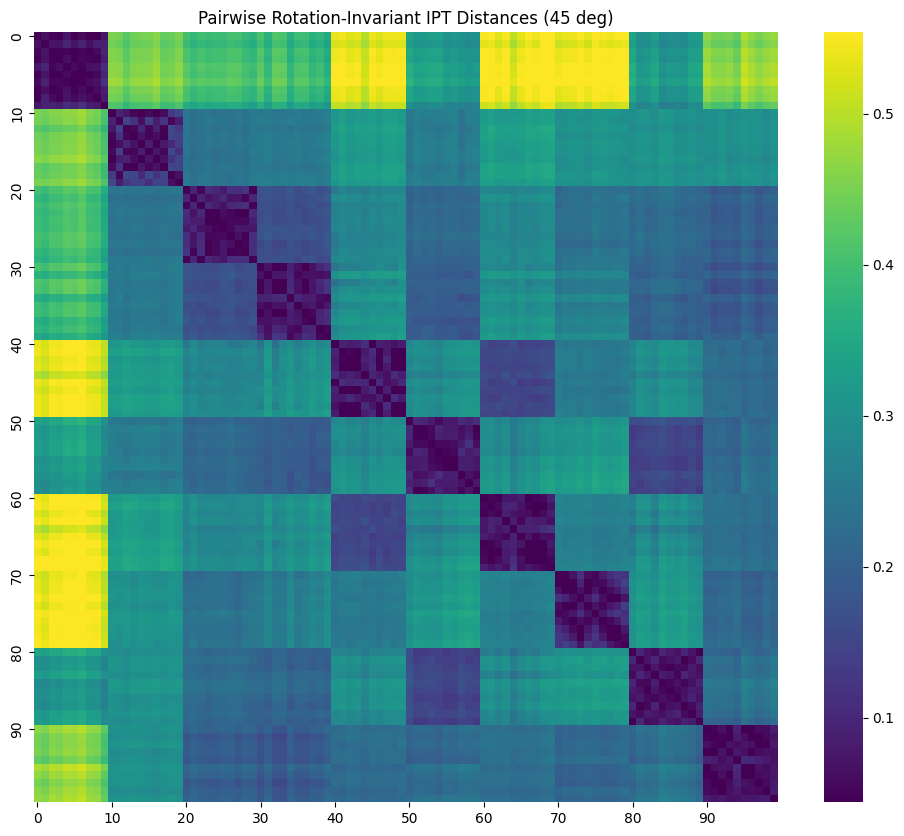

In [191]:
num_d = 15
num_t = 16
all_ipt = np.zeros((100, num_d, num_t))
for i in range(100):
    all_ipt[i] = compute_ipt(rotated_pt_cld[i], num_directions=num_d, num_thresholds=num_t, radius=1.0)

pairwise_distances = np.zeros((100, 100))
for i in range(100):
    for j in range(100):
        min = float('inf')
        for k in range(-num_d//4, num_d//4):
            d = IPT_metric(all_ipt[i], np.roll(all_ipt[j], -k-1, axis=0), n_pts=1024)
            if d < min:
                min = d
        pairwise_distances[i, j] = min
plt.figure(figsize=(12, 10))
plt.title("Pairwise Rotation-Invariant IPT Distances (45 deg)")
sns.heatmap(pairwise_distances, cmap='viridis', robust=True, xticklabels=10, yticklabels=10)
plt.show()

In [192]:
# Mean Intra class distance
import numpy as np

num_classes = 10
samples_per_class = 10
total_samples = num_classes * samples_per_class

mean_intra_dist = np.zeros(num_classes)
iu = np.triu_indices(samples_per_class, k=1) 

for i in range(num_classes):
    start, end = i * samples_per_class, (i + 1) * samples_per_class
    class_matrix = pairwise_distances[start:end, start:end]
    mean_intra_dist[i] = np.mean(class_matrix[iu])

print(f"Mean Intra class distance:\n{mean_intra_dist}\n")


mean_inter_dist = np.zeros(num_classes)
all_indices = np.arange(total_samples)

for i in range(num_classes):
    start, end = i * samples_per_class, (i + 1) * samples_per_class
    inter_mask = (all_indices < start) | (all_indices >= end)
    inter_matrix = pairwise_distances[start:end, inter_mask]
    mean_inter_dist[i] = np.mean(inter_matrix)

print(f"Mean Inter class distance:\n{mean_inter_dist}")

Mean Intra class distance:
[0.06377229 0.09211699 0.07768862 0.07469633 0.07161936 0.07597287
 0.06848133 0.0777179  0.07078811 0.06335259]

Mean Inter class distance:
[0.43951471 0.30593633 0.24758419 0.25074259 0.29432494 0.25120511
 0.29863539 0.30117906 0.25759427 0.25125652]


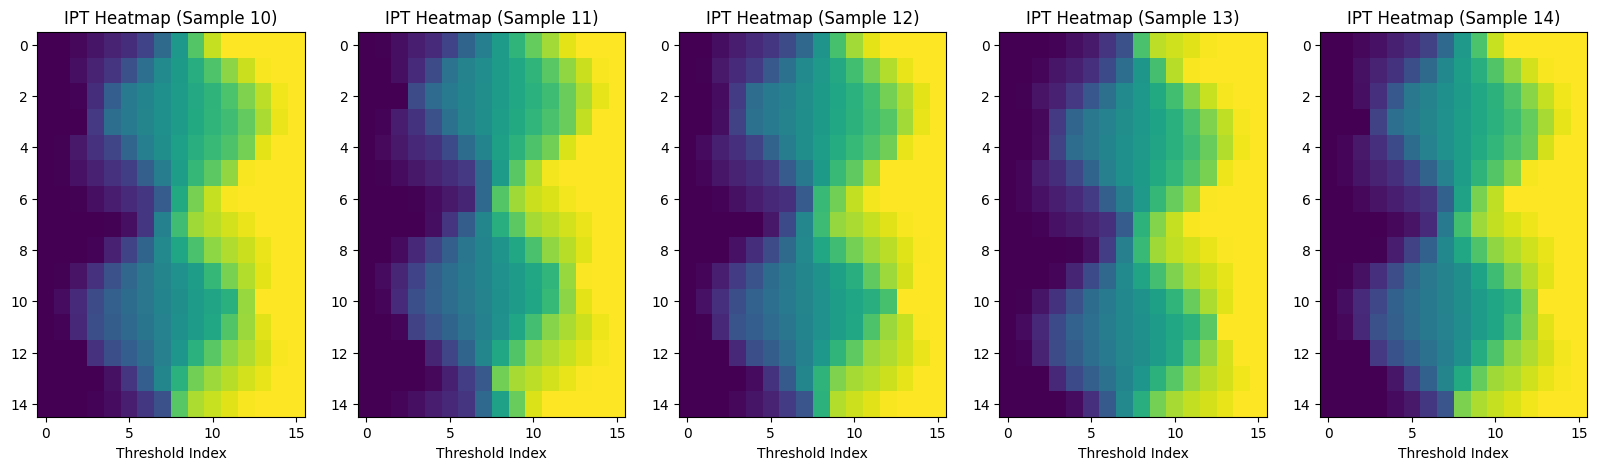

In [193]:
fig, ax = plt.subplots(1, 5, figsize=(20, 5))
j = 1
for i in range(5):
    ax[i].imshow(all_ipt[10*j + i], aspect='auto', cmap='viridis')
    ax[i].set_title(f'IPT Heatmap (Sample {10*j + i})')
    ax[i].set_xlabel('Threshold Index')